In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

In [10]:
#Loading data

train = pd.read_csv('train.csv', parse_dates=['date'])
test = pd.read_csv('test.csv', parse_dates=['date'])

# EDA

Train nulls: 0
Test nulls: 0


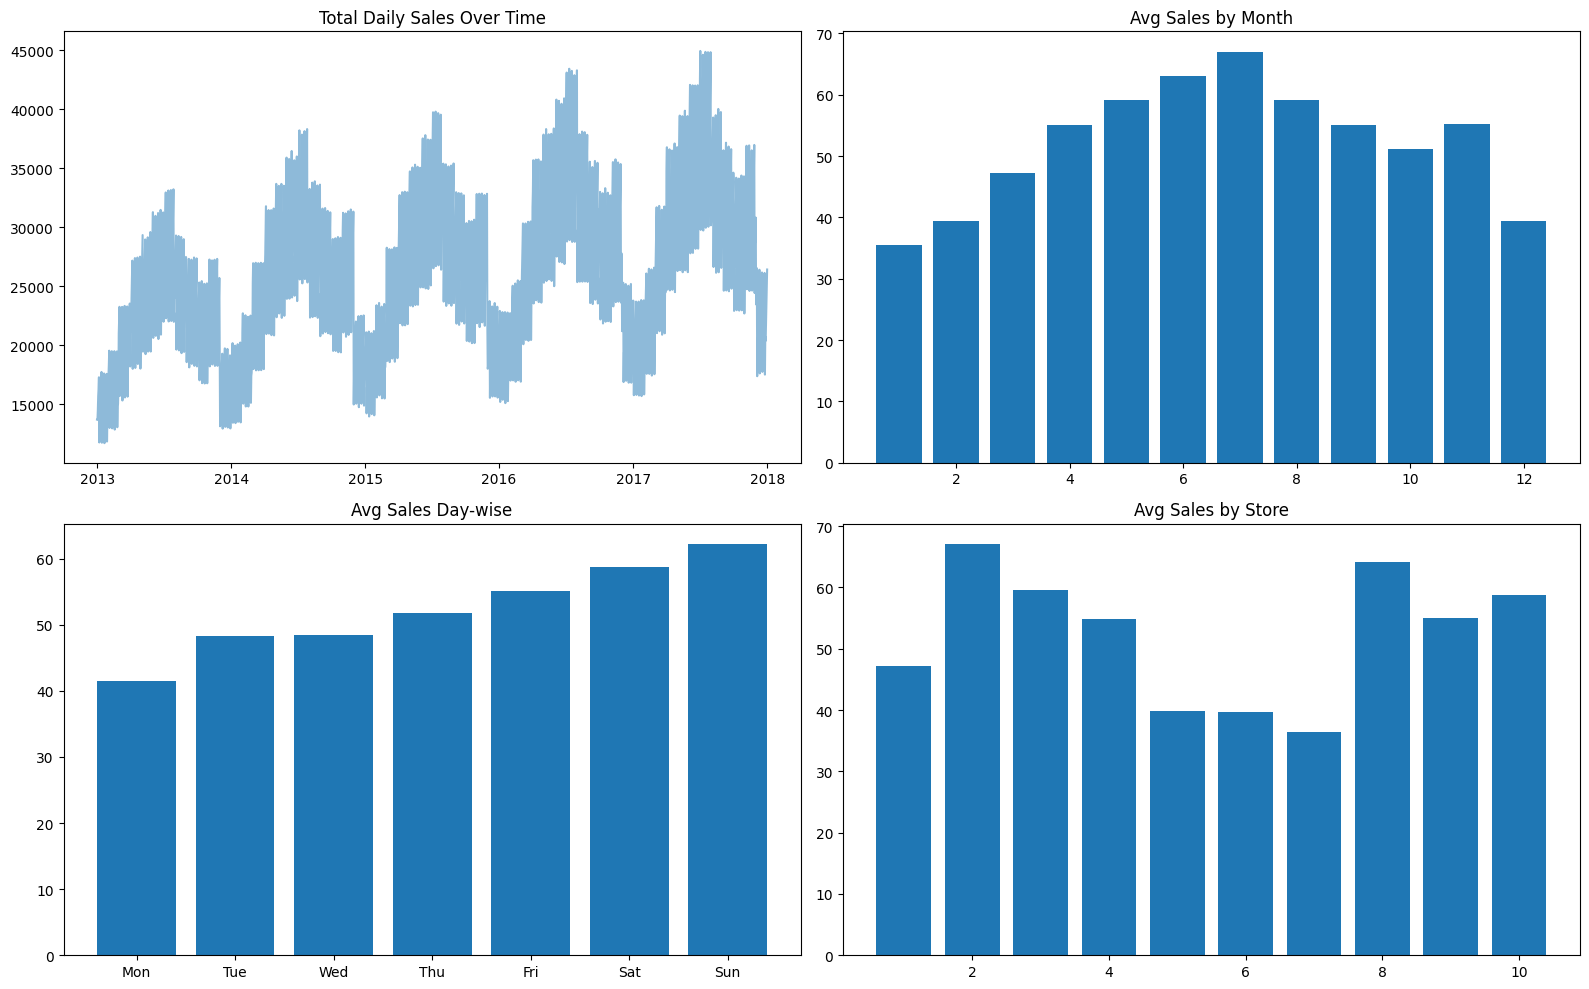

In [11]:
#Missing values
print("Train nulls:", train.isnull().sum().sum())
print("Test nulls:", test.isnull().sum().sum())

daily_total = train.groupby('date')['sales'].sum().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_total['date'], daily_total['sales'], alpha=0.5)
axes[0, 0].set_title('Total Daily Sales Over Time')

train['month'] = train['date'].dt.month
monthly_avg = train.groupby('month')['sales'].mean()
axes[0, 1].bar(monthly_avg.index, monthly_avg.values)
axes[0, 1].set_title('Avg Sales by Month')

train['dayofweek'] = train['date'].dt.dayofweek
dow_avg = train.groupby('dayofweek')['sales'].mean()
axes[1, 0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow_avg.values)
axes[1, 0].set_title('Avg Sales Day-wise')

store_avg = train.groupby('store')['sales'].mean()
axes[1, 1].bar(store_avg.index, store_avg.values)
axes[1, 1].set_title('Avg Sales by Store')
plt.tight_layout()
plt.show()

Conclusion:

- Sales increasing yearly
- Weekend sales are higher
- Store-level differences are there

# Feature Engineering

In [12]:
#combining train and test so lag features align properly
train['is_test'] = 0
test['is_test'] = 1
test['sales'] = np.nan
combined = pd.concat([train, test], ignore_index=True)
combined = combined.sort_values(['store', 'item', 'date']).reset_index(drop=True)

#date features
combined['year'] = combined['date'].dt.year
combined['month'] = combined['date'].dt.month
combined['day'] = combined['date'].dt.day
combined['dayofweek'] = combined['date'].dt.dayofweek
combined['dayofyear'] = combined['date'].dt.dayofyear
combined['week'] = combined['date'].dt.isocalendar().week.astype(int)
combined['quarter'] = combined['date'].dt.quarter
combined['is_weekend'] = (combined['dayofweek'] >= 5).astype(int)

#using sin/cos for month and dayofweek
combined['month_sin'] = np.sin(2 * np.pi * combined['month'] / 12)
combined['month_cos'] = np.cos(2 * np.pi * combined['month'] / 12)
combined['dow_sin'] = np.sin(2 * np.pi * combined['dayofweek'] / 7)
combined['dow_cos'] = np.cos(2 * np.pi * combined['dayofweek'] / 7)

# historical lags
print("building lags...")
for lag in [1, 7, 14, 28, 365]:
    print(f"  lag {lag}...")
    combined[f'lag_{lag}'] = combined.groupby(['store', 'item'])['sales'].shift(lag)

# rolling averages
print("building rollings...")
for window in [7, 30]:
    combined[f'roll_mean_{window}'] = combined.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    combined[f'roll_std_{window}'] = combined.groupby(['store', 'item'])['sales'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).std())

# expanding mean
combined['exp_mean'] = combined.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean())

# day-of-year historical averages from training data only
print("building doy stats...")
train_temp = combined[combined['is_test'] == 0].copy()
doy_stats = train_temp.groupby(['store', 'item', 'dayofyear'])['sales'].agg(['mean', 'std']).reset_index()
doy_stats.columns = ['store', 'item', 'dayofyear', 'doy_mean', 'doy_std']
combined = combined.merge(doy_stats, on=['store', 'item', 'dayofyear'], how='left')

# split back into train and test
train_fe = combined[combined['is_test'] == 0].copy()
test_fe = combined[combined['is_test'] == 1].copy()

train_fe = train_fe.dropna(subset=['lag_365'])

building lags...
  lag 1...
  lag 7...
  lag 14...
  lag 28...
  lag 365...
building rollings...
building doy stats...


# Model training using LIGHTGBM

training model...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[90]	training's l1: 4.59374	valid_1's l1: 5.24199

Validation SMAPE: 10.4227%


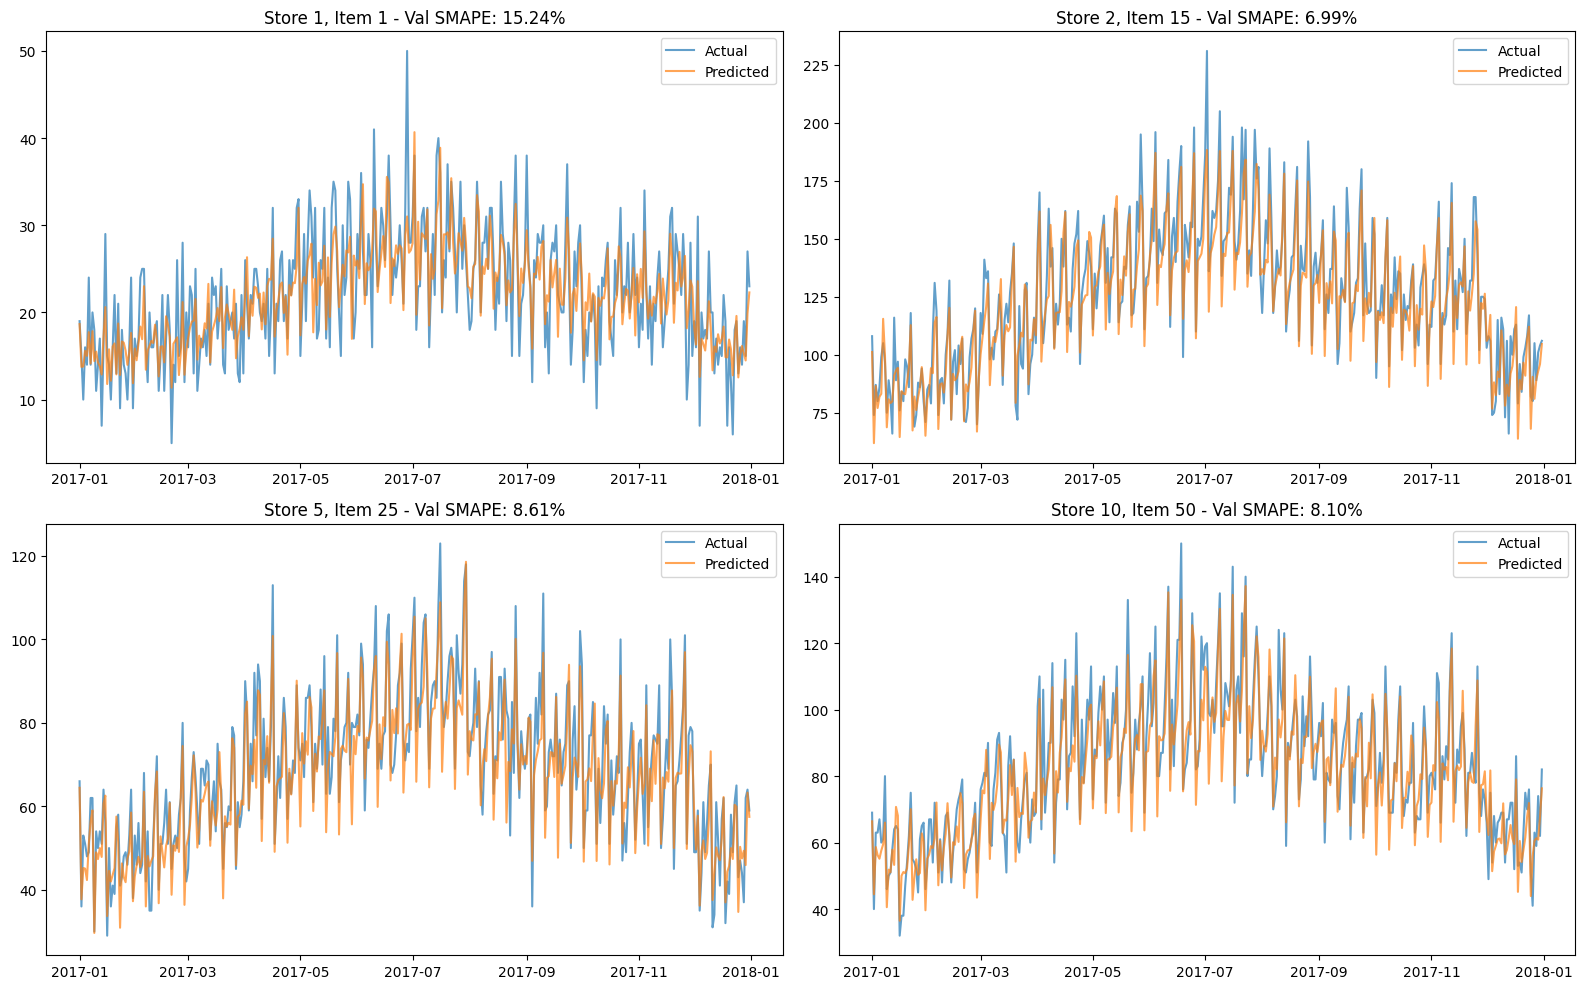

In [13]:
train_data = train_fe[train_fe['date'] < '2017-01-01']
val_data = train_fe[train_fe['date'] >= '2017-01-01']

exclude_cols = ['date', 'sales', 'is_test', 'id']
feature_cols = [c for c in train_fe.columns if c not in exclude_cols]

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return 100 * np.nanmean(diff)

lgb_params = {
    'objective': 'regression', 'metric': 'mae', 'learning_rate': 0.05,
    'num_leaves': 128, 'max_depth': 10, 'min_child_samples': 50,
    'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 5,
    'n_estimators': 2000, 'verbose': -1, 'random_state': 42, 'n_jobs': -1
}

print("training model...")
lgb_train = lgb.Dataset(train_data[feature_cols], train_data['sales'])
lgb_val = lgb.Dataset(val_data[feature_cols], val_data['sales'], reference=lgb_train)

model = lgb.train(lgb_params, lgb_train, valid_sets=[lgb_train, lgb_val],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])

# checking validation score
val_preds = np.clip(model.predict(val_data[feature_cols]), 0, None)
print(f"\nValidation SMAPE: {smape(val_data['sales'].values, val_preds):.4f}%")

# plotting actual vs predicted
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sample_combos = [(1, 1), (2, 15), (5, 25), (10, 50)]
for idx, (s, i) in enumerate(sample_combos):
    ax = axes[idx // 2][idx % 2]
    subset = val_data[(val_data['store'] == s) & (val_data['item'] == i)].copy()
    subset['pred'] = np.clip(model.predict(subset[feature_cols]), 0, None)

    ax.plot(subset['date'], subset['sales'], label='Actual', alpha=0.7)
    ax.plot(subset['date'], subset['pred'], label='Predicted', alpha=0.7)
    ax.set_title(f'Store {s}, Item {i} - Val SMAPE: {smape(subset["sales"].values, subset["pred"].values):.2f}%')
    ax.legend()
plt.tight_layout()
plt.show()

# Retraining the model on full data

In [14]:
print("retraining on full data...")
final_params = lgb_params.copy()
final_params['n_estimators'] = model.best_iteration + 50

final_model = lgb.train(final_params, lgb.Dataset(train_fe[feature_cols], train_fe['sales']),
                        callbacks=[lgb.log_evaluation(0)])

test_preds = np.clip(final_model.predict(test_fe[feature_cols]), 0, None)
test_preds = np.round(test_preds).astype(int)

retraining on full data...


# Final submission

In [15]:
submission = pd.DataFrame({'id': test['id'], 'sales': test_preds})
submission.to_csv('submission.csv', index=False)